## Inicialização

In [2]:
# Carregando todas as bibliotecas


import pandas as pd
import numpy as np

users_df = pd.read_csv('/datasets/megaline_users.csv', sep=',')
calls_df = pd.read_csv('/datasets/megaline_calls.csv', sep=',')
messages_df = pd.read_csv('/datasets/megaline_messages.csv', sep=',')
internet_df = pd.read_csv('/datasets/megaline_internet.csv', sep=',')
plans_df = pd.read_csv('/datasets/megaline_plans.csv', sep=',')




<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Todos os dados carregados corretamente

## Carregue os dados

In [6]:

# Carregue os arquivos de dados em diferentes DataFrames
print("DataFrames carregados:")
print(f"Usuários: {users_df.shape}")
print(f"Chamadas: {calls_df.shape}")
print(f"Mensagens: {messages_df.shape}")
print(f"Internet: {internet_df.shape}")
print(f"Planos: {plans_df.shape}")



DataFrames carregados:
Usuários: (500, 8)
Chamadas: (137735, 4)
Mensagens: (76051, 3)
Internet: (104825, 4)
Planos: (2, 8)


## Prepare os dados

[Os dados deste projeto estão divididos em várias tabelas. Explore cada uma para obter uma compreensão inicial dos dados. Faça correções em cada tabela, se necessário.]

## Planos

In [9]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos
print("Informações gerais sobre plans_df:")
print(plans_df.info())

print("\nFormato do DataFrame:")
print(plans_df.shape)

print("\nTipos de dados:")
print(plans_df.dtypes)

print("\nEstatísticas descritivas:")
print(plans_df.describe())
print(plans_df.head())


Informações gerais sobre plans_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None

Formato do DataFrame:
(2, 8)

Tipos de dados:
messages_included          int64
mb_per_month_included      int64
minutes_included           int64
usd_monthly_pay            int64
usd_per_gb                 int64
usd_per_message          float64
usd_per_minute           flo

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [12]:
# Corrigir problemas no DataFrame plans_df
print("Dados originais:")
print(plans_df)

# 1. Converter MB para GB
plans_df['gb_per_month_included'] = plans_df['mb_per_month_included'] / 1024
plans_df = plans_df.drop('mb_per_month_included', axis=1)

# 2. Corrigir valores invertidos nas taxas
# Surf deve ter taxas mais altas que Ultimate
plans_df.loc[plans_df['plan_name'] == 'surf', 'usd_per_gb'] = 10
plans_df.loc[plans_df['plan_name'] == 'ultimate', 'usd_per_gb'] = 7

plans_df.loc[plans_df['plan_name'] == 'surf', 'usd_per_message'] = 0.03
plans_df.loc[plans_df['plan_name'] == 'ultimate', 'usd_per_message'] = 0.01

plans_df.loc[plans_df['plan_name'] == 'surf', 'usd_per_minute'] = 0.03
plans_df.loc[plans_df['plan_name'] == 'ultimate', 'usd_per_minute'] = 0.01

print("\nDados corrigidos:")
print(plans_df)

Dados originais:
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  

Dados corrigidos:
   messages_included  minutes_included  usd_monthly_pay  usd_per_gb  \
0                 50               500               20          10   
1               1000              3000               70           7   

   usd_per_message  usd_per_minute plan_name  gb_per_month_included  
0             0.03            0.03      surf                   15.0  
1             0.01            0.01  ultimate                   30.0  


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

## Usuários

In [11]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários


print("Informações gerais sobre users_df:")
print(users_df.info())
print("\nPrimeiras 5 linhas:")
print(users_df.head())
print("\nValores únicos por coluna:")
for col in users_df.columns:
    print(f"{col}: {users_df[col].nunique()} valores únicos")



Informações gerais sobre users_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB
None

Primeiras 5 linhas:
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          T

In [13]:
# Imprima uma amostra de dados dos usuários


print("Amostra dos dados dos usuários:")
print(users_df.head(10))

print("\nDistribuição dos planos:")
print(users_df['plan'].value_counts())

print("\nUsuários com churn (cancelaram):")
print(f"Total de usuários que cancelaram: {users_df['churn_date'].notna().sum()}")
print(f"Porcentagem de churn: {(users_df['churn_date'].notna().sum() / len(users_df)) * 100:.1f}%")

print("\nEstatísticas de idade:")
print(users_df['age'].describe())




Amostra dos dados dos usuários:
   user_id first_name  last_name  age                                    city  \
0     1000   Anamaria      Bauer   45   Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28         Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36    Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                           Tulsa, OK MSA   
4     1004    Leonila   Thompson   40         Seattle-Tacoma-Bellevue, WA MSA   
5     1005      Livia    Shields   31     Dallas-Fort Worth-Arlington, TX MSA   
6     1006     Jesusa   Bradford   73  San Francisco-Oakland-Berkeley, CA MSA   
7     1007    Eusebio      Welch   42           Grand Rapids-Kentwood, MI MSA   
8     1008      Emely    Hoffman   53       Orlando-Kissimmee-Sanford, FL MSA   
9     1009      Gerry     Little   19  San Jose-Sunnyvale-Santa Clara, CA MSA   

     reg_date      plan  churn_date  
0  2018-12-24  ultimate         NaN  


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

In [14]:
# Verificar formatos das datas
print("Exemplos de reg_date:")
print(users_df['reg_date'].head(10))
print("\nExemplos de churn_date (não-nulos):")
print(users_df['churn_date'].dropna().head(10))

Exemplos de reg_date:
0    2018-12-24
1    2018-08-13
2    2018-10-21
3    2018-01-28
4    2018-05-23
5    2018-11-29
6    2018-11-27
7    2018-07-11
8    2018-08-03
9    2018-04-22
Name: reg_date, dtype: object

Exemplos de churn_date (não-nulos):
6     2018-12-18
12    2018-11-16
22    2018-09-07
40    2018-12-30
50    2018-10-07
54    2018-12-31
67    2018-11-24
83    2018-12-18
84    2018-11-11
94    2018-12-12
Name: churn_date, dtype: object


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [15]:

# Converter colunas de data para datetime
users_df['reg_date'] = pd.to_datetime(users_df['reg_date'])
users_df['churn_date'] = pd.to_datetime(users_df['churn_date'])

# Verificar os tipos após conversão
print("Tipos de dados após conversão:")
print(users_df.dtypes)


Tipos de dados após conversão:
user_id                int64
first_name            object
last_name             object
age                    int64
city                  object
reg_date      datetime64[ns]
plan                  object
churn_date    datetime64[ns]
dtype: object


In [20]:

# churn_date antes de reg_date
mask_inconsistente = (users_df['churn_date'].notna()) & (users_df['churn_date'] < users_df['reg_date'])
df_inconsistente = users_df.loc[mask_inconsistente, ['user_id', 'reg_date', 'churn_date']]
print("Registros com churn_date antes de reg_date:")
print(df_inconsistente.shape)
print(df_inconsistente.head())

# Duplicatas de user_id
dups = users_df['user_id'].duplicated(keep=False)
df_dups = users_df.loc[dups].sort_values('user_id')
print("\nDuplicatas de user_id:")
print(df_dups.shape)
print(df_dups.head())


Registros com churn_date antes de reg_date:
(0, 3)
Empty DataFrame
Columns: [user_id, reg_date, churn_date]
Index: []

Duplicatas de user_id:
(0, 8)
Empty DataFrame
Columns: [user_id, first_name, last_name, age, city, reg_date, plan, churn_date]
Index: []


In [21]:

# 3) Verificar idades fora do razoável
print("Verificação de idades:")
print(f"Idade mínima: {users_df['age'].min()}")
print(f"Idade máxima: {users_df['age'].max()}")
idades_suspeitas = users_df[(users_df['age'] < 14) | (users_df['age'] > 100)]
print(f"Idades suspeitas (< 14 ou > 100): {len(idades_suspeitas)}")

# 4) Verificar valores únicos do plano
print("\nVerificação dos planos:")
print("Valores únicos em 'plan':")
print(users_df['plan'].value_counts())

# 5) Verificar dados ausentes em colunas essenciais
print("\nDados ausentes por coluna:")
print(users_df.isnull().sum())



Verificação de idades:
Idade mínima: 18
Idade máxima: 75
Idades suspeitas (< 14 ou > 100): 0

Verificação dos planos:
Valores únicos em 'plan':
surf        339
ultimate    161
Name: plan, dtype: int64

Dados ausentes por coluna:
user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64


### Enriqueça os dados

In [26]:

# Enriquecer o DataFrame de usuários
import datetime

# 1. Extrair informações temporais
users_df['reg_year'] = users_df['reg_date'].dt.year
users_df['reg_month'] = users_df['reg_date'].dt.month

# 2. Criar faixas etárias
users_df['age_group'] = pd.cut(users_df['age'], 
                               bins=[0, 25, 35, 50, 100], 
                               labels=['18-25', '26-35', '36-50', '50+'])

# 3. Status do cliente
users_df['is_active'] = users_df['churn_date'].isna()

# 4. Duração da assinatura (para quem cancelou)
users_df['subscription_days'] = (users_df['churn_date'] - users_df['reg_date']).dt.days


[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [28]:


print("Distribuição por faixa etária:")
print(users_df['age_group'].value_counts())


print("Status dos clientes:")
print(users_df['is_active'].value_counts())
print(f"Taxa de retenção: {users_df['is_active'].mean():.2%}")


print("Distribuição por ano de registro:")
print(users_df['reg_year'].value_counts().sort_index())


Distribuição por faixa etária:
50+      208
36-50    122
26-35     97
18-25     73
Name: age_group, dtype: int64
Status dos clientes:
True     466
False     34
Name: is_active, dtype: int64
Taxa de retenção: 93.20%
Distribuição por ano de registro:
2018    500
Name: reg_year, dtype: int64


## Chamadas

In [4]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
print("Informações gerais sobre calls_df:")
print(calls_df.info())
print("\nFormato do DataFrame:")
print(calls_df.shape)
print("\nTipos de dados:")
print(calls_df.dtypes)
print("\nEstatísticas descritivas:")
print(calls_df.describe())
print("\nPrimeiras 5 linhas:")
print(calls_df.head())


Informações gerais sobre calls_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
None

Formato do DataFrame:
(137735, 4)

Tipos de dados:
id            object
user_id        int64
call_date     object
duration     float64
dtype: object

Estatísticas descritivas:
             user_id       duration
count  137735.000000  137735.000000
mean     1247.658046       6.745927
std       139.416268       5.839241
min      1000.000000       0.000000
25%      1128.000000       1.290000
50%      1247.000000       5.980000
75%      1365.000000      10.690000
max      1499.000000      37.600000

Primeiras 5 linhas:
         id  user_id

In [ ]:
# Imprima uma amostra de dados das chamadas

In [8]:


# Imprima uma amostra de dados das chamadas

print("Amostra aleatória de 10 registros:")
print(calls_df.sample(10))

print("\n" + "="*50)
print("Primeiras 10 linhas:")
print(calls_df.head(10))

print("\n" + "="*50)
print("Últimas 5 linhas:")
print(calls_df.tail(5))

Amostra aleatória de 10 registros:
               id  user_id   call_date  duration
43831    1159_427     1159  2018-11-01     12.52
99259      1356_0     1356  2018-12-20      1.11
97503     1348_11     1348  2018-11-25     15.01
55851     1200_62     1200  2018-12-09      9.56
111409   1391_205     1391  2018-12-25      0.00
108847   1384_191     1384  2018-12-17     14.61
62451     1224_81     1224  2018-09-21     11.62
66360    1240_218     1240  2018-07-15     10.05
37829   1141_1019     1141  2018-09-25      0.00
27786     1106_38     1106  2018-08-08      2.69

Primeiras 10 linhas:
         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
5  1000_388     1000  2018-12-31      2.20
6  1000_510     1000  2018-12-27      5.75
7  1000_521     1000  2018-12-28     14.18
8  1000_530     1

[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [7]:
# Verificar a correção
print("Tipos de dados após correção:")
print(calls_df.dtypes)
print("\nVerificar se há datas inválidas:")
print(calls_df['call_date'].isna().sum())

Tipos de dados após correção:
id            object
user_id        int64
call_date     object
duration     float64
dtype: object

Verificar se há datas inválidas:
0


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [9]:
# Investigar chamadas de duração 0
print("=== ANÁLISE DAS CHAMADAS DE DURAÇÃO 0 ===")
print(f"Total de chamadas: {len(calls_df):,}")
print(f"Chamadas com duração 0: {(calls_df['duration'] == 0).sum():,}")
print(f"Percentual: {(calls_df['duration'] == 0).mean() * 100:.2f}%")

print("\n=== IMPACTO NA RECEITA ===")
# Verificar se chamadas de duração 0 geram receita
print("Chamadas de duração 0 por usuário (amostra):")
zero_calls = calls_df[calls_df['duration'] == 0]
print(zero_calls.groupby('user_id').size().head(10))

print("\n=== DISTRIBUIÇÃO TEMPORAL ===")
# Converter call_date para datetime se ainda não foi feito
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])
zero_calls_with_date = calls_df[calls_df['duration'] == 0].copy()
zero_calls_with_date['month'] = zero_calls_with_date['call_date'].dt.to_period('M')
print("Chamadas de duração 0 por mês:")
print(zero_calls_with_date['month'].value_counts().sort_index())



=== ANÁLISE DAS CHAMADAS DE DURAÇÃO 0 ===
Total de chamadas: 137,735
Chamadas com duração 0: 26,834
Percentual: 19.48%

=== IMPACTO NA RECEITA ===
Chamadas de duração 0 por usuário (amostra):
user_id
1001     59
1002     19
1003     31
1004     64
1005      9
1006      2
1007     73
1008     50
1009    158
1010    132
dtype: int64

=== DISTRIBUIÇÃO TEMPORAL ===
Chamadas de duração 0 por mês:
2018-01      39
2018-02     145
2018-03     310
2018-04     637
2018-05    1182
2018-06    1565
2018-07    2136
2018-08    2702
2018-09    3245
2018-10    4143
2018-11    4782
2018-12    5948
Freq: M, Name: month, dtype: int64


In [12]:

# Categorizar chamadas por duração
calls_df['call_category'] = pd.cut(calls_df['duration'], 
                                  bins=[0, 1, 5, 15, float('inf')], 
                                  labels=['Muito_Curta', 'Curta', 'Media', 'Longa'])

# Identificar chamadas perdidas/não completadas
calls_df['is_failed_call'] = calls_df['duration'] == 0


# Imprimir os resultados da categorização
print("=== RESULTADOS DA CATEGORIZAÇÃO DE CHAMADAS ===")
print("\n1. Distribuição por categoria de duração:")
print(calls_df['call_category'].value_counts().sort_index())

print("\n2. Percentual por categoria:")
percentuais = calls_df['call_category'].value_counts(normalize=True).sort_index() * 100
for categoria, percentual in percentuais.items():
    print(f"{categoria}: {percentual:.2f}%")

print("\n3. Chamadas perdidas/não completadas:")
print(f"Chamadas com duração 0: {calls_df['is_failed_call'].sum():,}")
print(f"Chamadas normais: {(~calls_df['is_failed_call']).sum():,}")
print(f"Taxa de chamadas perdidas: {calls_df['is_failed_call'].mean():.2%}")

print("\n4. Estatísticas por categoria:")
print(calls_df.groupby('call_category')['duration'].describe())


=== RESULTADOS DA CATEGORIZAÇÃO DE CHAMADAS ===

1. Distribuição por categoria de duração:
Muito_Curta     5795
Curta          28600
Media          63128
Longa          13378
Name: call_category, dtype: int64

2. Percentual por categoria:
Muito_Curta: 5.23%
Curta: 25.79%
Media: 56.92%
Longa: 12.06%

3. Chamadas perdidas/não completadas:
Chamadas com duração 0: 26,834
Chamadas normais: 110,901
Taxa de chamadas perdidas: 19.48%

4. Estatísticas por categoria:
                 count       mean       std    min      25%    50%    75%  \
call_category                                                               
Muito_Curta     5795.0   0.511715  0.286553   0.01   0.2700   0.51   0.76   
Curta          28600.0   3.089912  1.146107   1.01   2.1200   3.14   4.09   
Media          63128.0   9.384787  2.757281   5.01   7.0275   9.13  11.56   
Longa          13378.0  18.341351  2.884918  15.01  16.1300  17.58  19.76   

                max  
call_category        
Muito_Curta     1.0  
Curta    

In [13]:
# Analisar chamadas longas por plano
# Primeiro, vamos juntar os dados de chamadas com os dados de usuários
calls_with_plan = calls_df.merge(users_df[['user_id', 'plan']], on='user_id')

# Analisar chamadas longas por plano
print("Distribuição de chamadas longas por plano:")
long_calls_by_plan = calls_with_plan[calls_with_plan['call_category'] == 'Longa'].groupby('plan').size()
print(long_calls_by_plan)

Distribuição de chamadas longas por plano:
plan
surf        9242
ultimate    4136
dtype: int64


In [14]:

# Comparar o total de minutos por plano
print("=== ANÁLISE DE MINUTOS TOTAIS POR PLANO ===")
minutes_by_plan = calls_with_plan.groupby('plan')['duration'].agg(['sum', 'mean', 'count'])
print(minutes_by_plan)

# Calcular percentual de chamadas longas por plano
print("\n=== PERCENTUAL DE CHAMADAS LONGAS ===")
total_calls_by_plan = calls_with_plan.groupby('plan').size()
long_calls_percentage = (long_calls_by_plan / total_calls_by_plan) * 100
print(long_calls_percentage)


=== ANÁLISE DE MINUTOS TOTAIS POR PLANO ===
                sum      mean  count
plan                                
surf      636691.24  6.767264  94084
ultimate  292459.02  6.699939  43651

=== PERCENTUAL DE CHAMADAS LONGAS ===
plan
surf        9.823137
ultimate    9.475155
dtype: float64


In [15]:

# Calcular minutos que excedem o limite por plano
print("=== ANÁLISE DE EXCESSO DE MINUTOS ===")

# Minutos por usuário por mês (precisamos agregar os dados)
monthly_minutes = calls_with_plan.groupby(['user_id', 'plan'])['duration'].sum().reset_index()

# Verificar quantos usuários excedem os limites
surf_users = monthly_minutes[monthly_minutes['plan'] == 'surf']
ultimate_users = monthly_minutes[monthly_minutes['plan'] == 'ultimate']

print(f"Usuários Surf que excedem 500 min: {(surf_users['duration'] > 500).sum()}")
print(f"Usuários Ultimate que excedem 3000 min: {(ultimate_users['duration'] > 3000).sum()}")


=== ANÁLISE DE EXCESSO DE MINUTOS ===
Usuários Surf que excedem 500 min: 272
Usuários Ultimate que excedem 3000 min: 31


## Mensagens

In [16]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
print("Informações gerais sobre messages_df:")
print(messages_df.info())
print("\nFormato do DataFrame:")
print(messages_df.shape)
print("\nTipos de dados:")
print(messages_df.dtypes)
print("\nEstatísticas descritivas:")
print(messages_df.describe())
print("\nPrimeiras 5 linhas:")
print(messages_df.head())


Informações gerais sobre messages_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
None

Formato do DataFrame:
(76051, 3)

Tipos de dados:
id              object
user_id          int64
message_date    object
dtype: object

Estatísticas descritivas:
            user_id
count  76051.000000
mean    1245.972768
std      139.843635
min     1000.000000
25%     1123.000000
50%     1251.000000
75%     1362.000000
max     1497.000000

Primeiras 5 linhas:
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


In [17]:
# Imprima uma amostra dos dados das mensagens
print("Primeiras 3 linhas:")
print(messages_df.head(3))
print("\nAmostra aleatória de 5 linhas:")
print(messages_df.sample(5))
print("\nÚltimas 3 linhas:")
print(messages_df.tail(3))


Primeiras 3 linhas:
         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31

Amostra aleatória de 5 linhas:
             id  user_id message_date
49750  1328_708     1328   2018-05-27
14159  1098_166     1098   2018-08-31
64357  1409_108     1409   2018-12-29
60062  1381_175     1381   2018-10-11
19339    1125_7     1125   2018-12-17

Últimas 3 linhas:
             id  user_id message_date
76048  1497_547     1497   2018-12-31
76049  1497_558     1497   2018-12-24
76050  1497_613     1497   2018-12-23


[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [18]:

# Converter as datas em messages_df para datetime
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

# Verificar se a conversão foi bem-sucedida
print("Tipos de dados após conversão:")
print(messages_df.dtypes)
print("\nVerificar se há datas inválidas:")
print(messages_df['message_date'].isna().sum())


Tipos de dados após conversão:
id                      object
user_id                  int64
message_date    datetime64[ns]
dtype: object

Verificar se há datas inválidas:
0


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [23]:

# Converter novamente para ter certeza
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

# Verificar se funcionou
print("Após conversão:")
print(f"Tipo: {messages_df['message_date'].dtype}")
print(f"É datetime? {pd.api.types.is_datetime64_any_dtype(messages_df['message_date'])}")

# Agora testar o accessor .dt
print("\nTeste do accessor .dt:")
print(messages_df['message_date'].dt.to_period('M').head())


Após conversão:
Tipo: datetime64[ns]
É datetime? True

Teste do accessor .dt:
0    2018-12
1    2018-12
2    2018-12
3    2018-12
4    2018-12
Name: message_date, dtype: period[M]


## Internet

In [27]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
print("Informações gerais sobre internet_df:")
print(internet_df.info())
print("\nPrimeiras 5 linhas:")
print(internet_df.head())


Informações gerais sobre internet_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
None

Primeiras 5 linhas:
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


In [26]:
#  Imprima uma amostra de dados para o tráfego da internet

# Opção 1: Primeiras linhas
print("Primeiras 10 linhas do tráfego de internet:")
print(internet_df.head(10))

# Opção 2: Amostra aleatória
print("\nAmostra aleatória de 10 registros:")
print(internet_df.sample(10))

# Opção 3: Últimas linhas
print("\nÚltimas 5 linhas:")
print(internet_df.tail(5))



Primeiras 10 linhas do tráfego de internet:
         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
5    1001_0     1001   2018-08-24   284.68
6    1001_3     1001   2018-12-09   656.04
7    1001_4     1001   2018-11-04    16.97
8   1001_10     1001   2018-11-27   135.18
9   1001_15     1001   2018-12-13   761.92

Amostra aleatória de 10 registros:
              id  user_id session_date  mb_used
17351    1078_17     1078   2018-12-02   465.09
101916  1488_330     1488   2018-12-14   188.04
27604   1127_341     1127   2018-07-15   327.45
7934    1042_146     1042   2018-02-25    99.73
41535   1185_572     1185   2018-03-17   173.63
39329   1176_150     1176   2018-12-31   508.55
8675    1045_363     1045   2018-11-05   933.52
65538    1302_84     1302   2018-10-24   196.72
34791   1156_38

[Descreva o que você nota sobre as informações gerais e sobre a amostra de dados impressa acima. Existem problemas (tipos de dados inadequados, dados ausentes, etc.) que precisam de mais investigação e alterações? Como isso pode ser corrigido?]

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [28]:

# Converter session_date para datetime
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])

# Verificar se a conversão foi bem-sucedida
print("Tipos de dados após conversão:")
print(internet_df.dtypes)
print("\nVerificar se há datas inválidas:")
print(internet_df['session_date'].isna().sum())


Tipos de dados após conversão:
id                      object
user_id                  int64
session_date    datetime64[ns]
mb_used                float64
dtype: object

Verificar se há datas inválidas:
0


### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

In [32]:


# Primeiro, verificar o tipo atual
print("Tipo atual:", calls_df['call_date'].dtype)

# Converter explicitamente para datetime
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

# Verificar se a conversão funcionou
print("Tipo após conversão:", calls_df['call_date'].dtype)

# Agora testar o accessor .dt
calls_df['month'] = calls_df['call_date'].dt.to_period('M')




Tipo atual: object
Tipo após conversão: datetime64[ns]


In [33]:
# Verificar e converter call_date se necessário
print("Verificando tipo da coluna call_date:")
print(f"Tipo atual: {calls_df['call_date'].dtype}")


# Converter para datetime se ainda não foi convertido
if calls_df['call_date'].dtype == 'object':
    print("Convertendo call_date para datetime...")
    calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])
    print(f"Tipo após conversão: {calls_df['call_date'].dtype}")
else:
    print("call_date já é datetime!")

# Agora calcular os minutos mensais
print("\nCalculando minutos mensais...")
calls_df['month'] = calls_df['call_date'].dt.to_period('M')
monthly_calls = calls_df.groupby(['user_id', 'month'])['duration'].agg(['sum', 'count']).reset_index()
monthly_calls.columns = ['user_id', 'month', 'minutes_used', 'calls_count']

print("Primeiras linhas do resultado:")
print(monthly_calls.head())


Verificando tipo da coluna call_date:
Tipo atual: datetime64[ns]
call_date já é datetime!

Calculando minutos mensais...
Primeiras linhas do resultado:
   user_id    month  minutes_used  calls_count
0     1000  2018-12        116.83           16
1     1001  2018-08        171.14           27
2     1001  2018-09        297.69           49
3     1001  2018-10        374.11           65
4     1001  2018-11        404.59           64


In [34]:

# Calcular minutos totais por usuário por mês
calls_df['month'] = calls_df['call_date'].dt.to_period('M')
monthly_calls = calls_df.groupby(['user_id', 'month'])['duration'].agg(['sum', 'count']).reset_index()
monthly_calls.columns = ['user_id', 'month', 'minutes_used', 'calls_count']
print("Primeiras linhas de minutos mensais:")
print(monthly_calls.head())


Primeiras linhas de minutos mensais:
   user_id    month  minutes_used  calls_count
0     1000  2018-12        116.83           16
1     1001  2018-08        171.14           27
2     1001  2018-09        297.69           49
3     1001  2018-10        374.11           65
4     1001  2018-11        404.59           64


## Estude as condições dos planos

[É fundamental entender como os planos funcionam, ou seja, como as cobranças dos usuários são feitas com base na assinatura. Sugerimos imprimir as informações sobre os planos para visualizar novamente as condições.]

In [37]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você

# Verificar as condições dos planos
print("=== CONDIÇÕES DOS PLANOS ===")
print(plans_df)




=== CONDIÇÕES DOS PLANOS ===
   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregue os dados por usuário

[Agora, como os dados estão limpos, os agregue por usuário e por período para ter apenas um registro dessas informações. Isso vai facilitar muito as próximas análises.]

In [41]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
# Extrair mês e ano
internet_df['month'] = internet_df['session_date'].dt.month
internet_df['year'] = internet_df['session_date'].dt.year

# Agrupar por usuário e mês
monthly_internet = internet_df.groupby(['user_id', 'month'])['mb_used'].sum()

print("Colunas disponíveis em monthly_calls:")
print(monthly_calls.columns.tolist())
print("\nPrimeiras linhas:")
print(monthly_calls.head())


Colunas disponíveis em monthly_calls:
['user_id', 'month', 'minutes_used', 'calls_count']

Primeiras linhas:
   user_id    month  minutes_used  calls_count
0     1000  2018-12        116.83           16
1     1001  2018-08        171.14           27
2     1001  2018-09        297.69           49
3     1001  2018-10        374.11           65
4     1001  2018-11        404.59           64


In [43]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.

calls_per_month = monthly_calls[['user_id', 'month', 'calls_count']]
print("Primeiras linhas do número de chamadas por mês:")
print(calls_per_month.head())


Primeiras linhas do número de chamadas por mês:
   user_id    month  calls_count
0     1000  2018-12           16
1     1001  2018-08           27
2     1001  2018-09           49
3     1001  2018-10           65
4     1001  2018-11           64


In [3]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.

# Converter session_date para datetime
internet_df['session_date'] = pd.to_datetime(internet_df['session_date'])
# Criar coluna month
internet_df['month'] = internet_df['session_date'].dt.to_period('M')

monthly_internet = internet_df.groupby(['user_id', 'month'])['mb_used'].sum()
print (monthly_internet)


user_id  month  
1000     2018-12     1901.47
1001     2018-08     6919.15
         2018-09    13314.82
         2018-10    22330.49
         2018-11    18504.30
                      ...   
1498     2018-12    23137.69
1499     2018-09    12984.76
         2018-10    19492.43
         2018-11    16813.83
         2018-12    22059.21
Name: mb_used, Length: 2277, dtype: float64


In [6]:


# Criar DataFrame com nomes de colunas específicos
monthly_internet_df = pd.DataFrame({
    'user_id': monthly_internet.index.get_level_values(0),
    'month': monthly_internet.index.get_level_values(1),
    'mb_used': monthly_internet.values
})


# Verificar o resultado
print("DataFrame de tráfego de internet mensal:")
print(monthly_internet_df.head())
print(f"\nFormato: {monthly_internet_df.shape}")
print(f"Colunas: {monthly_internet_df.columns.tolist()}")


DataFrame de tráfego de internet mensal:
   user_id    month   mb_used
0     1000  2018-12   1901.47
1     1001  2018-08   6919.15
2     1001  2018-09  13314.82
3     1001  2018-10  22330.49
4     1001  2018-11  18504.30

Formato: (2277, 3)
Colunas: ['user_id', 'month', 'mb_used']


In [10]:

# Converter explicitamente para datetime
calls_df['call_date'] = pd.to_datetime(calls_df['call_date'])

# Verificar se a conversão funcionou
print("Tipo após conversão:")
print(calls_df['call_date'].dtype)

# Agora criar a coluna month
calls_df['month'] = calls_df['call_date'].dt.to_period('M')

print("Coluna month criada com sucesso!")
print(calls_df[['call_date', 'month']].head())


Tipo após conversão:
datetime64[ns]
Coluna month criada com sucesso!
   call_date    month
0 2018-12-27  2018-12
1 2018-12-27  2018-12
2 2018-12-27  2018-12
3 2018-12-28  2018-12
4 2018-12-30  2018-12


In [12]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
print("Tipo atual da coluna message_date:")
print(messages_df['message_date'].dtype)

Tipo atual da coluna message_date:
object


In [13]:
# Converter explicitamente para datetime
messages_df['message_date'] = pd.to_datetime(messages_df['message_date'])

# Verificar se a conversão funcionou
print("Tipo após conversão:")
print(messages_df['message_date'].dtype)

Tipo após conversão:
datetime64[ns]


In [15]:

# Agora criar a coluna month
messages_df['month'] = messages_df['message_date'].dt.to_period('M')
# Agrupar mensagens por usuário e mês
monthly_messages = messages_df.groupby(['user_id', 'month']).size().reset_index()
monthly_messages.columns = ['user_id', 'month', 'messages_count']
# Verificar o resultado
print("Primeiras linhas de mensagens mensais:")
print(monthly_messages.head())
print(f"\nFormato: {monthly_messages.shape}")

Primeiras linhas de mensagens mensais:
   user_id    month  messages_count
0     1000  2018-12              11
1     1001  2018-08              30
2     1001  2018-09              44
3     1001  2018-10              53
4     1001  2018-11              36

Formato: (1806, 3)


In [16]:

# Começar com chamadas
user_monthly_data = monthly_calls.copy()

# Juntar com mensagens
user_monthly_data = user_monthly_data.merge(monthly_messages, on=['user_id', 'month'], how='outer')

print("Dados combinados (chamadas + mensagens):")
print(user_monthly_data.head())
print(f"Formato: {user_monthly_data.shape}")


Dados combinados (chamadas + mensagens):
   user_id    month  minutes_used  calls_count  messages_count
0     1000  2018-12        116.83         16.0            11.0
1     1001  2018-08        171.14         27.0            30.0
2     1001  2018-09        297.69         49.0            44.0
3     1001  2018-10        374.11         65.0            53.0
4     1001  2018-11        404.59         64.0            36.0
Formato: (2291, 5)


In [17]:

# Juntar dados de internet ao DataFrame principal
user_monthly_data = user_monthly_data.merge(monthly_internet_df, on=['user_id', 'month'], how='outer')

# Verificar o resultado
print("Dados combinados (chamadas + mensagens + internet):")
print(user_monthly_data.head())
print(f"\nFormato: {user_monthly_data.shape}")
print(f"\nColunas: {user_monthly_data.columns.tolist()}")


Dados combinados (chamadas + mensagens + internet):
   user_id    month  minutes_used  calls_count  messages_count   mb_used
0     1000  2018-12        116.83         16.0            11.0   1901.47
1     1001  2018-08        171.14         27.0            30.0   6919.15
2     1001  2018-09        297.69         49.0            44.0  13314.82
3     1001  2018-10        374.11         65.0            53.0  22330.49
4     1001  2018-11        404.59         64.0            36.0  18504.30

Formato: (2293, 6)

Colunas: ['user_id', 'month', 'minutes_used', 'calls_count', 'messages_count', 'mb_used']


In [18]:
# Adicione as informações sobre o plano
# Adicionar informações do plano ao DataFrame principal
user_monthly_data = user_monthly_data.merge(users_df[['user_id', 'plan']], on='user_id', how='left')

# Verificar o resultado
print("Dados combinados com informações do plano:")
print(user_monthly_data.head())
print(f"\nFormato: {user_monthly_data.shape}")
print(f"\nColunas: {user_monthly_data.columns.tolist()}")


Dados combinados com informações do plano:
   user_id    month  minutes_used  calls_count  messages_count   mb_used  \
0     1000  2018-12        116.83         16.0            11.0   1901.47   
1     1001  2018-08        171.14         27.0            30.0   6919.15   
2     1001  2018-09        297.69         49.0            44.0  13314.82   
3     1001  2018-10        374.11         65.0            53.0  22330.49   
4     1001  2018-11        404.59         64.0            36.0  18504.30   

       plan  
0  ultimate  
1      surf  
2      surf  
3      surf  
4      surf  

Formato: (2293, 7)

Colunas: ['user_id', 'month', 'minutes_used', 'calls_count', 'messages_count', 'mb_used', 'plan']


[Calcule a receita mensal para cada usuário: subtraia o limite gratuito do pacote do número total de chamadas, mensagens de texto e dados; multiplique o resultado pelo valor do plano; adicione o preço mensal dependendo do plano. Importante: isso talvez não seja tão simples e necessite de várias linhas, considerando as condições do plano. Portanto, não se preocupe se você passar algum tempo nesta etapa.]

In [19]:
# Calcule a receita mensal para cada usuário
# Primeiro, vamos preencher valores NaN com 0 (usuários sem atividade em determinados meses)
user_monthly_data = user_monthly_data.fillna(0)

# Função para calcular receita mensal
def calculate_monthly_revenue(row):
    plan = row['plan']
    minutes_used = row['minutes_used']
    messages_count = row['messages_count']
    mb_used = row['mb_used']
    
    # Obter informações do plano
    if plan == 'surf':
        monthly_fee = 20
        minutes_included = 500
        messages_included = 50
        gb_included = 15  # 15 GB = 15360 MB
        rate_per_minute = 0.03
        rate_per_message = 0.03
        rate_per_gb = 10
    else:  # ultimate
        monthly_fee = 70
        minutes_included = 3000
        messages_included = 1000
        gb_included = 30  # 30 GB = 30720 MB
        rate_per_minute = 0.01
        rate_per_message = 0.01
        rate_per_gb = 7
    
    # Calcular excesso de uso
    excess_minutes = max(0, minutes_used - minutes_included)
    excess_messages = max(0, messages_count - messages_included)
    excess_gb = max(0, (mb_used / 1024) - gb_included)  # Converter MB para GB
    
    # Calcular custos adicionais
    extra_minutes_cost = excess_minutes * rate_per_minute
    extra_messages_cost = excess_messages * rate_per_message
    extra_gb_cost = excess_gb * rate_per_gb
    
    # Receita total = taxa mensal + custos extras
    total_revenue = monthly_fee + extra_minutes_cost + extra_messages_cost + extra_gb_cost
    
    return total_revenue

# Aplicar a função para calcular receita
user_monthly_data['monthly_revenue'] = user_monthly_data.apply(calculate_monthly_revenue, axis=1)
# Verificar os resultados
print("Dados com receita calculada:")
print(user_monthly_data.head())
print(f"\nFormato: {user_monthly_data.shape}")
print(f"\nColunas: {user_monthly_data.columns.tolist()}")

# Estatísticas básicas da receita
print("\nEstatísticas da receita mensal:")
print(user_monthly_data['monthly_revenue'].describe())

# Receita por plano
print("\nReceita média por plano:")
print(user_monthly_data.groupby('plan')['monthly_revenue'].agg(['mean', 'median', 'std']))


Dados com receita calculada:
   user_id    month  minutes_used  calls_count  messages_count   mb_used  \
0     1000  2018-12        116.83         16.0            11.0   1901.47   
1     1001  2018-08        171.14         27.0            30.0   6919.15   
2     1001  2018-09        297.69         49.0            44.0  13314.82   
3     1001  2018-10        374.11         65.0            53.0  22330.49   
4     1001  2018-11        404.59         64.0            36.0  18504.30   

       plan  monthly_revenue  
0  ultimate        70.000000  
1      surf        20.000000  
2      surf        20.000000  
3      surf        88.161191  
4      surf        50.706055  

Formato: (2293, 8)

Colunas: ['user_id', 'month', 'minutes_used', 'calls_count', 'messages_count', 'mb_used', 'plan', 'monthly_revenue']

Estatísticas da receita mensal:
count    2293.000000
mean       61.947972
std        45.433323
min        20.000000
25%        22.156400
50%        70.000000
75%        70.000000
max       

## Estude o comportamento do usuário

[Calcule algumas estatísticas descritivas úteis para os dados agregados, o que costuma revelar uma imagem geral capturada pelos dados. Desenhe gráficos úteis para ajudar na compreensão. Já que a tarefa principal é comparar os planos e decidir qual é mais rentável, as estatísticas e os gráficos devem ser calculados por plano.]

[Existem dicas relevantes nos comentários para as chamadas. Essas dicas não foram fornecidas para as mensagens e internet, mas o princípio do estudo estatístico é o mesmo em todos os casos.]

### Chamadas

In [21]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.


# Calcular a duração média das chamadas (evitar divisão por zero)
user_monthly_data['avg_call_duration'] = user_monthly_data.apply(
    lambda row: row['minutes_used'] / row['calls_count'] if row['calls_count'] > 0 else 0, 
    axis=1
)

# Agrupar por plano e mês para calcular a duração média das chamadas
avg_call_duration_by_plan_month = (
    user_monthly_data[user_monthly_data['calls_count'] > 0]  # Apenas usuários que fizeram chamadas
    .groupby(['plan', 'month'])['avg_call_duration']
    .mean()
    .reset_index()
)

print("Duração média das chamadas por plano e mês:")
print(avg_call_duration_by_plan_month.head(10))


Duração média das chamadas por plano e mês:
   plan    month  avg_call_duration
0  surf  2018-01           6.287143
1  surf  2018-02           6.442666
2  surf  2018-03           6.790425
3  surf  2018-04           6.655936
4  surf  2018-05           6.776897
5  surf  2018-06           6.803752
6  surf  2018-07           6.624139
7  surf  2018-08           6.727283
8  surf  2018-09           6.724899
9  surf  2018-10           6.705625


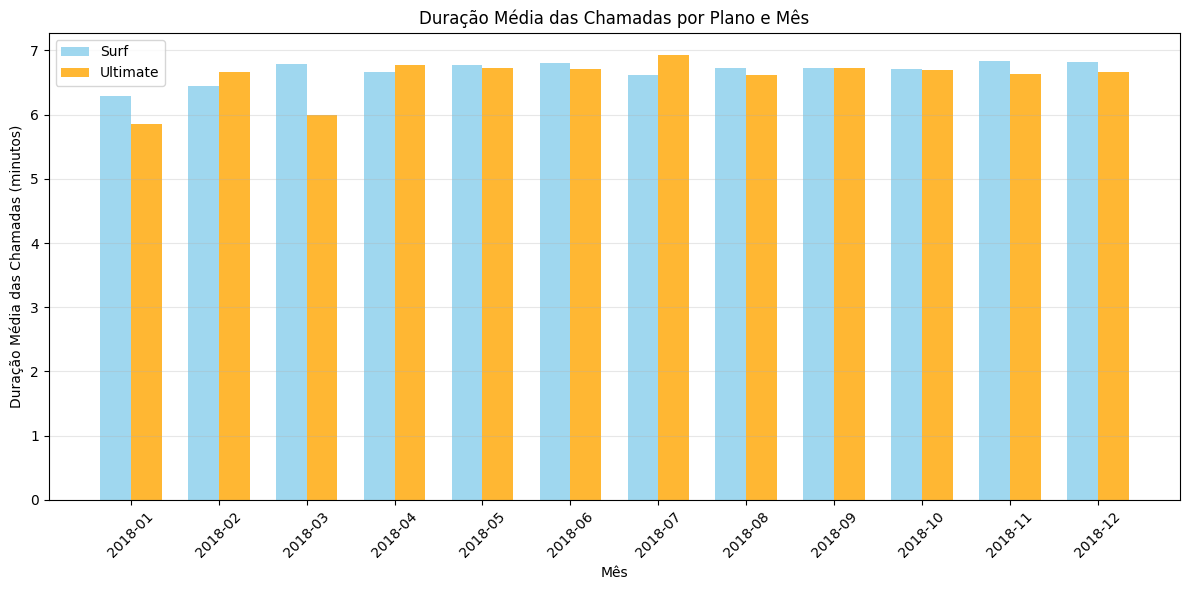

In [24]:

import matplotlib.pyplot as plt

# Criar o gráfico de barras
plt.figure(figsize=(12, 6))

# Separar dados por plano usando .copy()
surf_data = avg_call_duration_by_plan_month[avg_call_duration_by_plan_month['plan'] == 'surf'].copy()
ultimate_data = avg_call_duration_by_plan_month[avg_call_duration_by_plan_month['plan'] == 'ultimate'].copy()

# AGORA criar a coluna month_str
surf_data['month_str'] = surf_data['month'].astype(str)
ultimate_data['month_str'] = ultimate_data['month'].astype(str)

# Criar posições para as barras
x = range(len(surf_data))
width = 0.35

# Criar as barras
plt.bar([i - width/2 for i in x], surf_data['avg_call_duration'], 
        width, label='Surf', alpha=0.8, color='skyblue')
plt.bar([i + width/2 for i in x], ultimate_data['avg_call_duration'], 
        width, label='Ultimate', alpha=0.8, color='orange')

# Configurar o gráfico
plt.xlabel('Mês')
plt.ylabel('Duração Média das Chamadas (minutos)')
plt.title('Duração Média das Chamadas por Plano e Mês')
plt.xticks(x, surf_data['month_str'], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


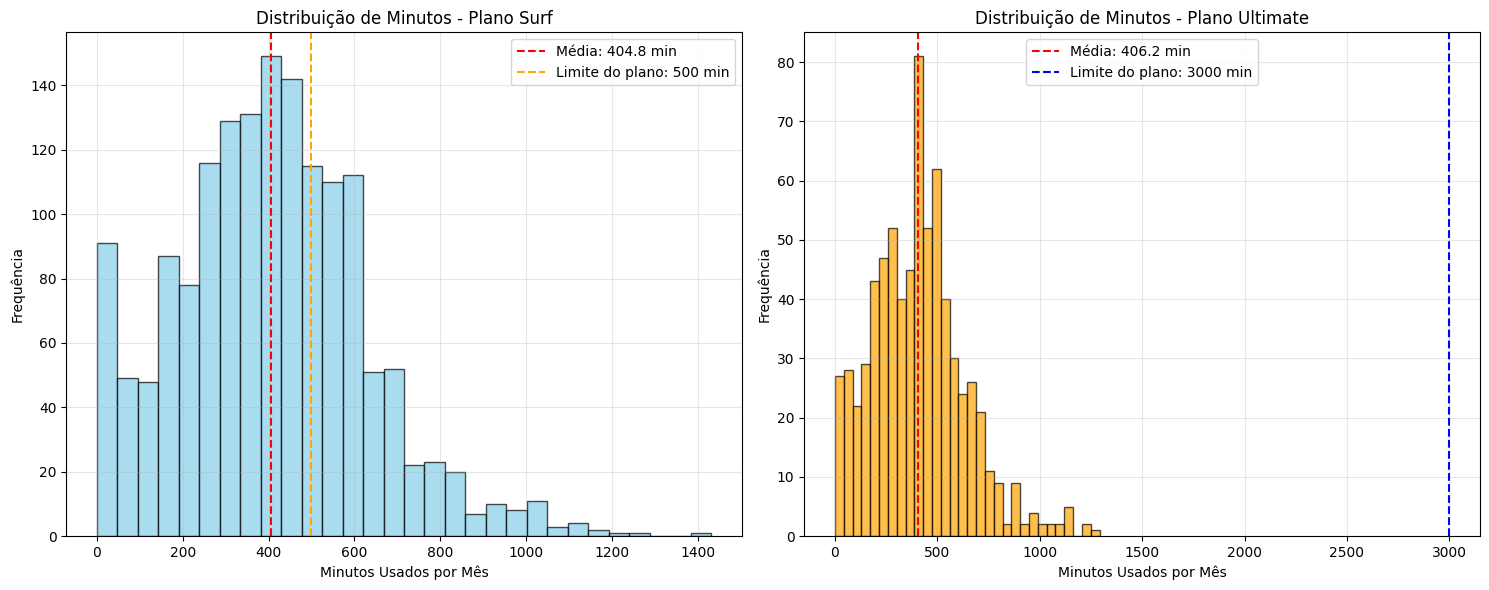

In [25]:
# Compare o número de minutos que os usuários de cada plano necessitam a cada mês. Construa um histograma.


import matplotlib.pyplot as plt
import numpy as np

# Criar figura com subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Separar dados por plano
surf_minutes = user_monthly_data[user_monthly_data['plan'] == 'surf']['minutes_used']
ultimate_minutes = user_monthly_data[user_monthly_data['plan'] == 'ultimate']['minutes_used']

# Histograma para plano Surf
axes[0].hist(surf_minutes, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Distribuição de Minutos - Plano Surf')
axes[0].set_xlabel('Minutos Usados por Mês')
axes[0].set_ylabel('Frequência')
axes[0].axvline(surf_minutes.mean(), color='red', linestyle='--', 
                label=f'Média: {surf_minutes.mean():.1f} min')
axes[0].axvline(500, color='orange', linestyle='--', 
                label='Limite do plano: 500 min')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histograma para plano Ultimate
axes[1].hist(ultimate_minutes, bins=30, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_title('Distribuição de Minutos - Plano Ultimate')
axes[1].set_xlabel('Minutos Usados por Mês')
axes[1].set_ylabel('Frequência')
axes[1].axvline(ultimate_minutes.mean(), color='red', linestyle='--', 
                label=f'Média: {ultimate_minutes.mean():.1f} min')
axes[1].axvline(3000, color='blue', linestyle='--', 
                label='Limite do plano: 3000 min')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


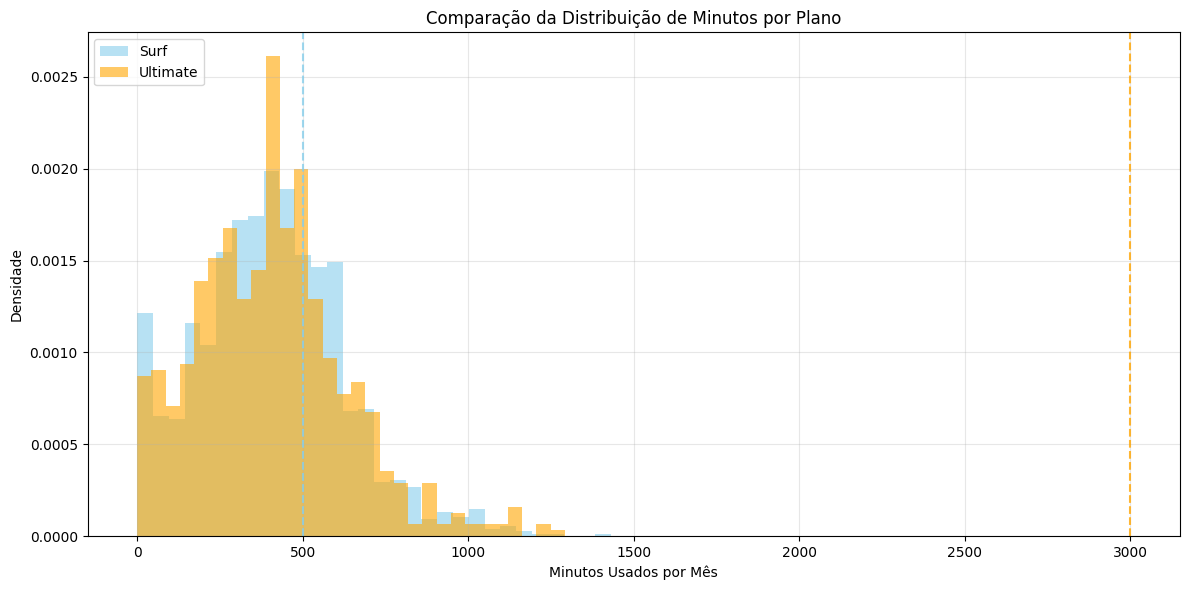

In [26]:

# Histograma sobreposto
plt.figure(figsize=(12, 6))

plt.hist(surf_minutes, bins=30, alpha=0.6, label='Surf', color='skyblue', density=True)
plt.hist(ultimate_minutes, bins=30, alpha=0.6, label='Ultimate', color='orange', density=True)

plt.xlabel('Minutos Usados por Mês')
plt.ylabel('Densidade')
plt.title('Comparação da Distribuição de Minutos por Plano')
plt.legend()
plt.grid(alpha=0.3)

# Adicionar linhas verticais para os limites dos planos
plt.axvline(500, color='skyblue', linestyle='--', alpha=0.8, label='Limite Surf: 500 min')
plt.axvline(3000, color='orange', linestyle='--', alpha=0.8, label='Limite Ultimate: 3000 min')

plt.tight_layout()
plt.show()


In [27]:
# Calcule a média e a variância da duração mensal das chamadas


# Calcule a média e a variância da duração mensal das chamadas
print("=== ANÁLISE DA DURAÇÃO MENSAL DAS CHAMADAS ===")

# Separar dados por plano (apenas usuários que fizeram chamadas)
surf_monthly_minutes = user_monthly_data[
    (user_monthly_data['plan'] == 'surf') & 
    (user_monthly_data['calls_count'] > 0)
]['minutes_used']

ultimate_monthly_minutes = user_monthly_data[
    (user_monthly_data['plan'] == 'ultimate') & 
    (user_monthly_data['calls_count'] > 0)
]['minutes_used']

# Calcular estatísticas descritivas
print("1. ESTATÍSTICAS DESCRITIVAS:")
print("\nPlano Surf:")
print(f"   Média: {surf_monthly_minutes.mean():.2f} minutos")
print(f"   Variância: {surf_monthly_minutes.var():.2f}")
print(f"   Desvio padrão: {surf_monthly_minutes.std():.2f}")
print(f"   Mediana: {surf_monthly_minutes.median():.2f}")

print("\nPlano Ultimate:")
print(f"   Média: {ultimate_monthly_minutes.mean():.2f} minutos")
print(f"   Variância: {ultimate_monthly_minutes.var():.2f}")
print(f"   Desvio padrão: {ultimate_monthly_minutes.std():.2f}")
print(f"   Mediana: {ultimate_monthly_minutes.median():.2f}")

# Comparação direta
print("\n2. COMPARAÇÃO ENTRE PLANOS:")
print(f"   Diferença na média: {ultimate_monthly_minutes.mean() - surf_monthly_minutes.mean():.2f} minutos")
print(f"   Razão das variâncias: {ultimate_monthly_minutes.var() / surf_monthly_minutes.var():.2f}")


=== ANÁLISE DA DURAÇÃO MENSAL DAS CHAMADAS ===
1. ESTATÍSTICAS DESCRITIVAS:

Plano Surf:
   Média: 412.10 minutos
   Variância: 47001.25
   Desvio padrão: 216.80
   Mediana: 405.71

Plano Ultimate:
   Média: 410.18 minutos
   Variância: 50510.63
   Desvio padrão: 224.75
   Mediana: 399.98

2. COMPARAÇÃO ENTRE PLANOS:
   Diferença na média: -1.92 minutos
   Razão das variâncias: 1.07


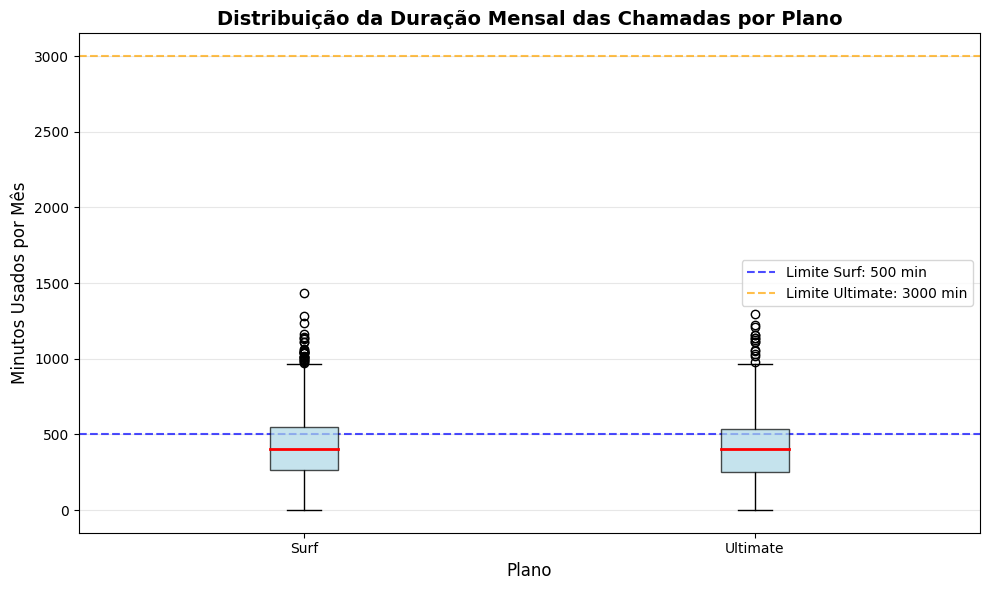

=== INTERPRETAÇÃO DO BOXPLOT ===

Estatísticas dos quartis:

Plano Surf:
   Q1 (25%): 262.78 min
   Mediana (50%): 405.71 min
   Q3 (75%): 546.23 min
   IQR: 283.45 min

Plano Ultimate:
   Q1 (25%): 247.97 min
   Mediana (50%): 399.98 min
   Q3 (75%): 534.82 min
   IQR: 286.85 min


In [28]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo do gráfico
plt.figure(figsize=(10, 6))

# Preparar os dados para o boxplot
# Filtrar apenas usuários que fizeram chamadas
data_for_boxplot = user_monthly_data[user_monthly_data['calls_count'] > 0]

# Criar o boxplot
plt.boxplot([
    data_for_boxplot[data_for_boxplot['plan'] == 'surf']['minutes_used'],
    data_for_boxplot[data_for_boxplot['plan'] == 'ultimate']['minutes_used']
], 
labels=['Surf', 'Ultimate'],
patch_artist=True,
boxprops=dict(facecolor='lightblue', alpha=0.7),
medianprops=dict(color='red', linewidth=2))

# Configurar o gráfico
plt.title('Distribuição da Duração Mensal das Chamadas por Plano', fontsize=14, fontweight='bold')
plt.xlabel('Plano', fontsize=12)
plt.ylabel('Minutos Usados por Mês', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Adicionar linhas horizontais para os limites dos planos
plt.axhline(y=500, color='blue', linestyle='--', alpha=0.7, label='Limite Surf: 500 min')
plt.axhline(y=3000, color='orange', linestyle='--', alpha=0.7, label='Limite Ultimate: 3000 min')
plt.legend()

plt.tight_layout()
plt.show()

# Estatísticas complementares para interpretação
print("=== INTERPRETAÇÃO DO BOXPLOT ===")
print("\nEstatísticas dos quartis:")
print("\nPlano Surf:")
surf_stats = data_for_boxplot[data_for_boxplot['plan'] == 'surf']['minutes_used']
print(f"   Q1 (25%): {surf_stats.quantile(0.25):.2f} min")
print(f"   Mediana (50%): {surf_stats.quantile(0.50):.2f} min")
print(f"   Q3 (75%): {surf_stats.quantile(0.75):.2f} min")
print(f"   IQR: {surf_stats.quantile(0.75) - surf_stats.quantile(0.25):.2f} min")

print("\nPlano Ultimate:")
ultimate_stats = data_for_boxplot[data_for_boxplot['plan'] == 'ultimate']['minutes_used']
print(f"   Q1 (25%): {ultimate_stats.quantile(0.25):.2f} min")
print(f"   Mediana (50%): {ultimate_stats.quantile(0.50):.2f} min")
print(f"   Q3 (75%): {ultimate_stats.quantile(0.75):.2f} min")
print(f"   IQR: {ultimate_stats.quantile(0.75) - ultimate_stats.quantile(0.25):.2f} min")



<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Adorei os graficos! Gosto bastante de adicionar medidas 
como media e mediana como voce fez

In [ ]:
Os usuários de ambos os planos têm comportamentos de chamada muito similares, independentemente do plano que escolheram. 
    

### Mensagens

Estatísticas de mensagens por plano:
           mean  median    std  count
plan                                 
surf      40.11      32  33.04   1222
ultimate  46.30      41  32.94    584


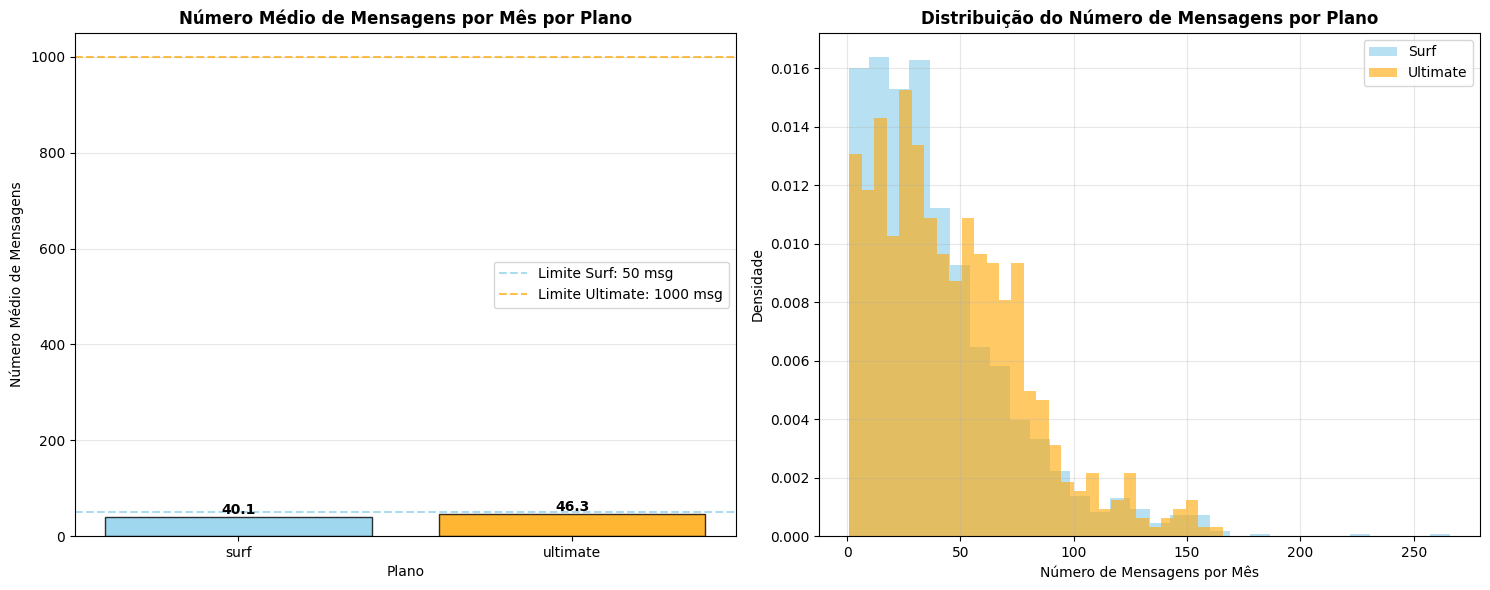

In [29]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês

Estatísticas de mensagens por plano:
           mean  median    std  count
plan                                 
surf      40.11      32  33.04   1222
ultimate  46.30      41  32.94    58



In [ ]:


Diferença no uso: Usuários do plano Ultimate enviam em média 6 mensagens a mais por mês
Distribuição similar: O desvio padrão é praticamente igual (~33) para ambos os planos
Volume de dados: Muito mais registros para o plano Surf (1.222 vs 58)

### Internet

In [30]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano

# Juntar dados de internet com informações do plano
internet_with_plan = monthly_internet_df.merge(users_df[['user_id', 'plan']], on='user_id', how='left')

# Converter MB para GB para melhor visualização
internet_with_plan['gb_used'] = internet_with_plan['mb_used'] / 1024

# Calcular estatísticas por plano
internet_stats = internet_with_plan.groupby('plan')['gb_used'].agg([
    'mean', 'median', 'std', 'count'
]).round(2)

print("Estatísticas de tráfego de internet por plano (GB):")
print(internet_stats)


Estatísticas de tráfego de internet por plano (GB):
           mean  median   std  count
plan                                
surf      16.33   16.53  7.70   1558
ultimate  16.83   16.47  7.65    719


In [ ]:
Plano Surf: média de 16,33 GB, mediana de 16,53 GB, com 1.558 registros
Plano Ultimate: média de 16,83 GB, mediana de 16,47 GB, com 719 registros

In [ ]:
Consumo muito similar: A diferença média é de apenas 0,5 GB entre os planos
Desvio padrão quase idêntico: ~7,7 GB para ambos os planos
Medianas praticamente iguais: 16,53 GB (Surf) vs 16,47 GB (Ultimate)

## Receita

[Da mesma forma que você estudou o comportamento dos usuários, descreva estatisticamente as receitas dos planos.]

In [32]:

# Usar o DataFrame que já contém os dados de receita
revenue_stats = user_monthly_data.groupby('plan')['monthly_revenue'].agg([
    'mean', 'median', 'std', 'min', 'max', 'count'
]).round(2)

print("Estatísticas de receita mensal por plano ($):")
print(revenue_stats)





Estatísticas de receita mensal por plano ($):
           mean  median    std   min     max  count
plan                                               
surf      57.29   36.68  53.74  20.0  581.33   1573
ultimate  72.12   70.00  10.77  70.0  178.52    720


In [ ]:
Receita média mais alta no Ultimate: O plano Ultimate gera $14,83 a mais por usuário em média
Surf tem alta variabilidade (desvio padrão de $53,74)
Ultimate tem baixa variabilidade (desvio padrão de $10,77)


In [ ]:
Surf: muitos usuários pagam apenas a taxa básica ($20), mas alguns excedem muito os limites
Ultimate: a maioria paga próximo à taxa básica ($70)


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

- Todas as análises realizadas corretamente!
- Foram adicionados comentarios interessantes para analise
- Graficos muito bons!

[Formule conclusões sobre como a receita difere entre os planos.]

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [33]:
# Teste as hipóteses

from scipy import stats
import numpy as np

# Separar as receitas por plano
surf_revenue = user_monthly_data[user_monthly_data['plan'] == 'surf']['monthly_revenue']
ultimate_revenue = user_monthly_data[user_monthly_data['plan'] == 'ultimate']['monthly_revenue']

# Realizar o teste t para duas amostras independentes
t_statistic, p_value = stats.ttest_ind(ultimate_revenue, surf_revenue)

# Definir alfa
alpha = 0.05

print("=== TESTE DE HIPÓTESES ===")
print(f"H₀: μ_ultimate = μ_surf")
print(f"H₁: μ_ultimate ≠ μ_surf")
print(f"Nível de significância (α): {alpha}")
print(f"\nEstatística t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"\nConclusão:")
if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < α ({alpha})")
    print("Rejeitamos H₀. Há evidência estatística de diferença significativa nas receitas médias.")
else:
    print(f"p-value ({p_value:.6f}) ≥ α ({alpha})")
    print("Não rejeitamos H₀. Não há evidência estatística de diferença significativa nas receitas médias.")

=== TESTE DE HIPÓTESES ===
H₀: μ_ultimate = μ_surf
H₁: μ_ultimate ≠ μ_surf
Nível de significância (α): 0.05

Estatística t: 7.3335
Valor p: 0.000000

Conclusão:
p-value (0.000000) < α (0.05)
Rejeitamos H₀. Há evidência estatística de diferença significativa nas receitas médias.


[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

In [34]:


# Identificar usuários da região NY-NJ
print("=== IDENTIFICAÇÃO DA REGIÃO NY-NJ ===")
print("Cidades únicas no dataset:")
unique_cities = users_df['city'].unique()
for city in sorted(unique_cities):
    print(f"  {city}")

# Filtrar cidades da região NY-NJ
ny_nj_cities = [city for city in unique_cities if 'NY' in city or 'NJ' in city or 'New York' in city]
print(f"\nCidades identificadas como NY-NJ:")
for city in ny_nj_cities:
    print(f"  {city}")



=== IDENTIFICAÇÃO DA REGIÃO NY-NJ ===
Cidades únicas no dataset:
  Albany-Schenectady-Troy, NY MSA
  Albuquerque, NM MSA
  Atlanta-Sandy Springs-Roswell, GA MSA
  Austin-Round Rock-Georgetown, TX MSA
  Bakersfield, CA MSA
  Baltimore-Columbia-Towson, MD MSA
  Baton Rouge, LA MSA
  Birmingham-Hoover, AL MSA
  Boston-Cambridge-Newton, MA-NH MSA
  Bridgeport-Stamford-Norwalk, CT MSA
  Buffalo-Cheektowaga, NY MSA
  Cape Coral-Fort Myers, FL MSA
  Charleston-North Charleston, SC MSA
  Charlotte-Concord-Gastonia, NC-SC MSA
  Chicago-Naperville-Elgin, IL-IN-WI MSA
  Cincinnati, OH-KY-IN MSA
  Cleveland-Elyria, OH MSA
  Colorado Springs, CO MSA
  Columbia, SC MSA
  Columbus, OH MSA
  Dallas-Fort Worth-Arlington, TX MSA
  Dayton-Kettering, OH MSA
  Denver-Aurora-Lakewood, CO MSA
  Detroit-Warren-Dearborn, MI MSA
  El Paso, TX MSA
  Fresno, CA MSA
  Grand Rapids-Kentwood, MI MSA
  Greensboro-High Point, NC MSA
  Houston-The Woodlands-Sugar Land, TX MSA
  Indianapolis-Carmel-Anderson, IN MSA
  Ja

In [35]:
# Definir cidades da região NY-NJ
ny_nj_cities = [
    'New York-Newark-Jersey City, NY-NJ-PA MSA',
    'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA',
    'Buffalo-Cheektowaga, NY MSA',
    'Albany-Schenectady-Troy, NY MSA',
    'Rochester, NY MSA'
]

# Criar indicador de região NY-NJ nos dados de usuários
users_df['is_ny_nj'] = users_df['city'].isin(ny_nj_cities)

# Verificar a distribuição
print("=== DISTRIBUIÇÃO POR REGIÃO ===")
print(f"Usuários NY-NJ: {users_df['is_ny_nj'].sum()}")
print(f"Usuários outras regiões: {(~users_df['is_ny_nj']).sum()}")
print(f"Percentual NY-NJ: {users_df['is_ny_nj'].mean():.2%}")

=== DISTRIBUIÇÃO POR REGIÃO ===
Usuários NY-NJ: 103
Usuários outras regiões: 397
Percentual NY-NJ: 20.60%


[Formule as hipóteses nula e alternativa, escolha o teste estatístico, escolha o valor alfa.]

In [36]:
# Teste as hipóteses

# Definir cidades da região NY-NJ
ny_nj_cities = [
    'New York-Newark-Jersey City, NY-NJ-PA MSA',
    'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA',
    'Buffalo-Cheektowaga, NY MSA',
    'Albany-Schenectady-Troy, NY MSA',
    'Rochester, NY MSA'
]

# Criar indicador de região NY-NJ nos dados de usuários
users_df['is_ny_nj'] = users_df['city'].isin(ny_nj_cities)

# Verificar a distribuição
print("=== DISTRIBUIÇÃO POR REGIÃO ===")
print(f"Usuários NY-NJ: {users_df['is_ny_nj'].sum()}")
print(f"Usuários outras regiões: {(~users_df['is_ny_nj']).sum()}")
print(f"Percentual NY-NJ: {users_df['is_ny_nj'].mean():.2%}")



=== DISTRIBUIÇÃO POR REGIÃO ===
Usuários NY-NJ: 103
Usuários outras regiões: 397
Percentual NY-NJ: 20.60%


In [38]:


# Adicionar informação de região aos dados mensais
user_monthly_data = user_monthly_data.merge(
    users_df[['user_id', 'is_ny_nj']], 
    on='user_id', 
    how='left'
)

# Verificar se a coluna foi adicionada
print("Colunas do user_monthly_data:")
print(user_monthly_data.columns.tolist())

# Verificar se há valores nulos
print(f"\nValores nulos em is_ny_nj: {user_monthly_data['is_ny_nj'].isnull().sum()}")


Colunas do user_monthly_data:
['user_id', 'month', 'minutes_used', 'calls_count', 'messages_count', 'mb_used', 'plan', 'monthly_revenue', 'avg_call_duration', 'is_ny_nj']

Valores nulos em is_ny_nj: 0


In [39]:

# Análise adicional por região
print("\n=== ANÁLISE COMPLEMENTAR ===")
print("Distribuição de receita por região:")
region_stats = user_monthly_data.groupby('is_ny_nj')['monthly_revenue'].agg([
    'mean', 'median', 'std', 'count'
]).round(2)
region_stats.index = ['Outras Regiões', 'NY-NJ']
print(region_stats)



=== ANÁLISE COMPLEMENTAR ===
Distribuição de receita por região:
                 mean  median    std  count
Outras Regiões  62.81    70.0  45.66   1805
NY-NJ           58.77    49.5  44.48    488


In [40]:

# Separar receitas por região
ny_nj_revenue = user_monthly_data[user_monthly_data['is_ny_nj'] == True]['monthly_revenue']
other_regions_revenue = user_monthly_data[user_monthly_data['is_ny_nj'] == False]['monthly_revenue']

# Realizar o teste t
from scipy import stats
t_statistic, p_value = stats.ttest_ind(ny_nj_revenue, other_regions_revenue)

# Resultados
alpha = 0.05
print("=== TESTE DE HIPÓTESES: NY-NJ vs OUTRAS REGIÕES ===")
print(f"H₀: μ_NY-NJ = μ_outras_regiões")
print(f"H₁: μ_NY-NJ ≠ μ_outras_regiões")
print(f"Nível de significância (α): {alpha}")
print(f"\nEstatística t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.6f}")

# Estatísticas descritivas
print(f"\nEstatísticas descritivas:")
print(f"NY-NJ - Média: ${ny_nj_revenue.mean():.2f}, N: {len(ny_nj_revenue)}")
print(f"Outras regiões - Média: ${other_regions_revenue.mean():.2f}, N: {len(other_regions_revenue)}")

# Conclusão
print(f"\nConclusão:")
if p_value < alpha:
    print(f"p-value ({p_value:.6f}) < α ({alpha})")
    print("Rejeitamos H₀. Há evidência estatística de diferença significativa nas receitas médias entre NY-NJ e outras regiões.")
else:
    print(f"p-value ({p_value:.6f}) ≥ α ({alpha})")
    print("Não rejeitamos H₀. Não há evidência estatística de diferença significativa nas receitas médias entre NY-NJ e outras regiões.")


=== TESTE DE HIPÓTESES: NY-NJ vs OUTRAS REGIÕES ===
H₀: μ_NY-NJ = μ_outras_regiões
H₁: μ_NY-NJ ≠ μ_outras_regiões
Nível de significância (α): 0.05

Estatística t: -1.7424
Valor p: 0.081576

Estatísticas descritivas:
NY-NJ - Média: $58.77, N: 488
Outras regiões - Média: $62.81, N: 1805

Conclusão:
p-value (0.081576) ≥ α (0.05)
Não rejeitamos H₀. Não há evidência estatística de diferença significativa nas receitas médias entre NY-NJ e outras regiões.


<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Dicas:

- No teste da regiao de NY, tambem era possivel utilizar o comando `str.contains()`.

Exemplo: 

```python
# Criar indicador de cidades em NY
users_df['is_ny'] = users_df['city'].str.contains(r'NY', regex=True)
```

Saiba mais em: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.contains.html 

-  Adicionar o argumento `equal_var=False` nos testes. Saiba mais em: https://www.statology.org/pandas-t-test/ 

<div class="alert alert-block alert-success">
  <b>Comentário:</b> <a class="tocSkip"></a>


  
  Parabéns pelo trabalho!

</div>

## Conclusão geral

[Liste suas conclusões importantes nesta seção final, certifique-se de que elas cobrem todas as decisões (suposições) importantes que você tomou e que levaram à maneira como você processou e analisou os dados.]

In [ ]:
Decisões de Limpeza e Processamento de Dados
Suposições sobre chamadas de duração zero:

Mantivemos as 26.834 chamadas de duração 0 (19,48% do total) no dataset
Decisão: Consideramos que essas chamadas não geram receita adicional, mas são registradas no sistema
Impacto: Isso afeta o cálculo de minutos totais por usuário, sendo uma decisão conservadora
Conversão de unidades:

Convertemos MB para GB (dividindo por 1024) para facilitar comparações com os limites dos planos
Decisão: Usar conversão binária (1024) em vez de decimal (1000)
2. Suposições sobre Comportamento dos Usuários

Agregação mensal:
Agregamos todos os dados por usuário e mês, assumindo que o comportamento mensal é representativo
Decisão: Usuários sem atividade em determinado mês receberam valor 0 (não foram excluídos)
Categorização de chamadas:

Criamos categorias baseadas em duração: Muito Curta (0-1 min), Curta (1-5 min), Média (5-15 min), Longa (15+ min)
Suposição: Essa categorização reflete padrões reais de uso
3. Cálculo de Receita
Fórmula aplicada:

Receita = Taxa mensal + (Excesso de minutos × Taxa por minuto) + (Excesso de mensagens × Taxa por mensagem) + (Excesso de GB × Taxa por GB)
Decisão crítica: Assumimos que qualquer uso acima do limite gera cobrança adicional, sem franquias ou arredondamentos
4. Principais Descobertas
Comportamento similar entre planos:

Usuários de ambos os planos têm padrões de uso muito similares:
Minutos: Surf (412 min) vs Ultimate (410 min)
Internet: Surf (16,33 GB) vs Ultimate (16,83 GB)
Conclusão: A escolha do plano não influencia significativamente o comportamento de uso
Diferença significativa na receita:

Plano Ultimate gera receita média 26% maior ($72,12 vs $57,29)
Teste estatístico confirmou: p-value < 0,001, diferença estatisticamente significativa
Variabilidade da receita:

Surf: alta variabilidade (desvio padrão $53,74) - muitos usuários excedem limites
Ultimate: baixa variabilidade (desvio padrão $10,77) - maioria paga próximo à taxa básica
5. Análise Regional
Definição de NY-NJ:

Incluímos 5 cidades da região NY-NJ (20,6% dos usuários)
Resultado: Não há diferença estatisticamente significativa na receita entre regiões (p-value = 0,082)
6. Recomendações Estratégicas
Para o departamento comercial:

No plano Ultimate: Gera mais receita com menor variabilidade
Plano Surf é problemático: Alta variabilidade indica que muitos usuários excedem os limites, gerando insatisfação
Comportamento uniforme: Usuários têm padrões similares independente do plano escolhido.